In [1]:
import datetime as dt
from src.preprocessing import preprocess_spy, preprocess_all_tickers, select_complete_tickers, count_tickers_with_expected_rows, plot_1min_intraday_midprices_and_returns, get_selected_tickers, load_selected_ticker_frames
from src.ocp import build_daily_return_matrices, build_daily_pairs, ocp_run_all_days_fast
from src.trading import OCPTradeParams, run_backtest, show_final_strat_results, show_sensitivity_analysis

from pathlib import Path
# Autorealod extension for Jupyter Notebooks
%load_ext autoreload
%autoreload 2

In [2]:
PARTIAL_RUN = True # Set to True to preprocess and analyze a subset of tickers and days for faster testing

## Preprocessing

In [3]:
preprocess_spy()

2026-01-24 10:47:42,461 | INFO | SPY BBO already preprocessed, loading from parquet.


timestamp,mid_price_return
"datetime[μs, America/New_York]",f64
2015-01-02 09:32:00 EST,0.000194
2015-01-02 09:33:00 EST,0.001114
2015-01-02 09:34:00 EST,0.000339
2015-01-02 09:35:00 EST,-0.000629
2015-01-02 09:36:00 EST,0.000629
…,…
2017-04-12 15:56:00 EDT,0.000085
2017-04-12 15:57:00 EDT,0.0
2017-04-12 15:58:00 EDT,-0.000043


In [4]:
if PARTIAL_RUN:
    tickers = [
        "MRK.N", "MMM.N", "BLK.N", "ALL.N", "BIIB.OQ", 
        "WFC.N", "FOXA.OQ", "CAT.N", "BMY.N", "DUK.N",
        "LOW.N", "PCLN.OQ", "GD.N", "CMCSA.OQ", "SO.N", 
        "GM.N", "KO.N", "COF.N", "AAPL.OQ"
    ]
else:
    tickers = None # Preprocess all tickers
preprocess_all_tickers(tickers)

2026-01-24 10:47:42,624 | INFO | Starting preprocessing of all tickers...
2026-01-24 10:47:42,628 | INFO | 0 tickers need preprocessing.


Preprocessing tickers: 0it [00:00, ?it/s]

2026-01-24 10:47:42,670 | INFO | 19 tickers processed successfully over 19 total.


In [5]:
select_complete_tickers(exception_dates=[dt.date(2015, 11, 27)], delete_exception_days=True)

2026-01-24 10:47:42,738 | INFO | Starting selection of complete tickers...
2026-01-24 10:47:44,927 | WARNING | [PYPL.OQ.parquet] Missing 136 trading days: [datetime.date(2015, 1, 2), datetime.date(2015, 1, 5), datetime.date(2015, 1, 6), datetime.date(2015, 1, 7), datetime.date(2015, 1, 8), datetime.date(2015, 1, 9), datetime.date(2015, 1, 12), datetime.date(2015, 1, 13), datetime.date(2015, 1, 14), datetime.date(2015, 1, 15), datetime.date(2015, 1, 16), datetime.date(2015, 1, 20), datetime.date(2015, 1, 21), datetime.date(2015, 1, 22), datetime.date(2015, 1, 23), datetime.date(2015, 1, 26), datetime.date(2015, 1, 27), datetime.date(2015, 1, 28), datetime.date(2015, 1, 29), datetime.date(2015, 1, 30), datetime.date(2015, 2, 2), datetime.date(2015, 2, 3), datetime.date(2015, 2, 4), datetime.date(2015, 2, 5), datetime.date(2015, 2, 6), datetime.date(2015, 2, 9), datetime.date(2015, 2, 10), datetime.date(2015, 2, 11), datetime.date(2015, 2, 12), datetime.date(2015, 2, 13), datetime.date(20

In [6]:
count_tickers_with_expected_rows()

2026-01-24 10:47:54,354 | INFO | Counting rows for each selected ticker...
2026-01-24 10:47:56,329 | INFO | Number of tickers with the expected number of rows: 91 out of 91


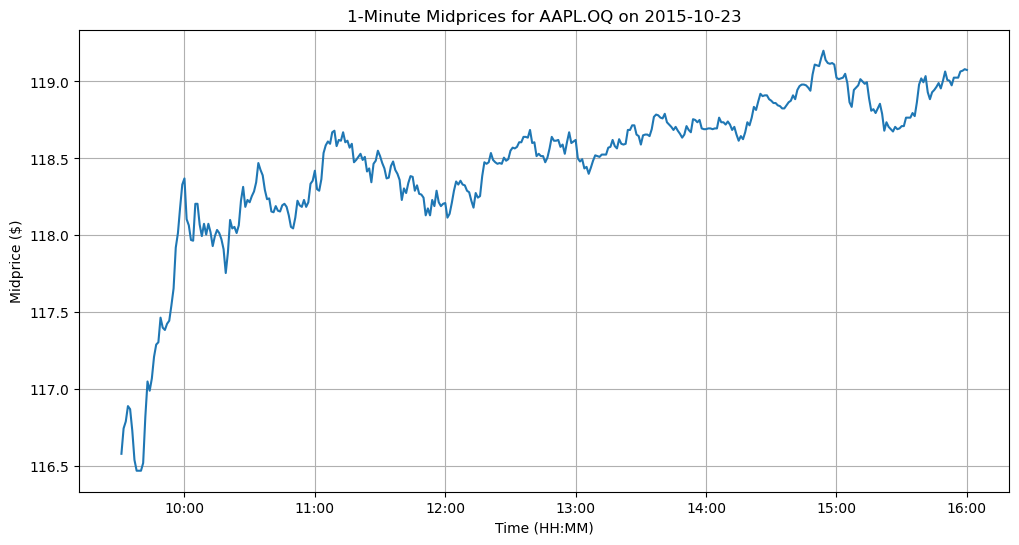

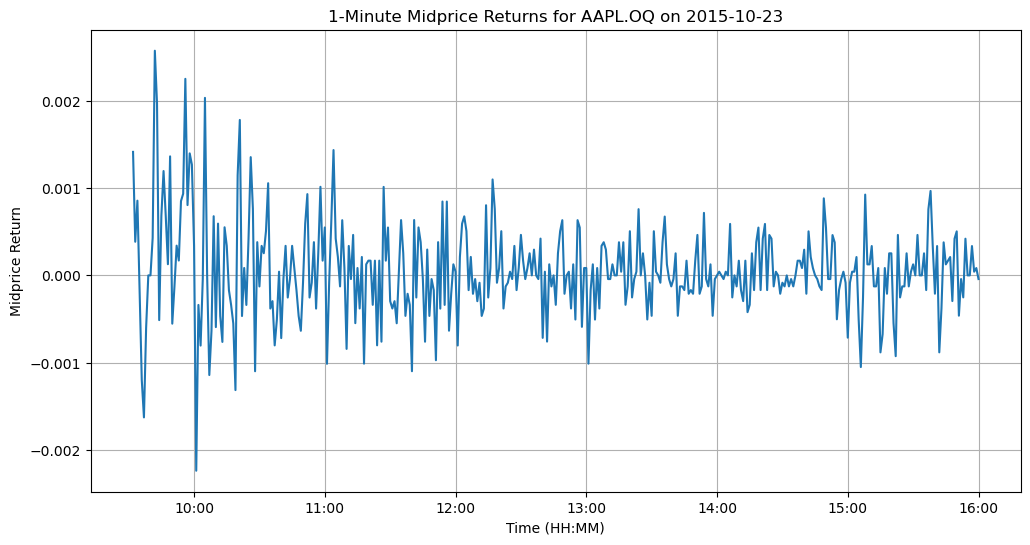

In [7]:
plot_1min_intraday_midprices_and_returns(ticker="AAPL.OQ", date=dt.date(2015, 10, 23))

## OCP algorithm

In [8]:
#1) Get selected tickers
if PARTIAL_RUN:
    tickers = [
    "MRK.N", "MMM.N", "BLK.N", "ALL.N", "BIIB.OQ", 
    "WFC.N", "FOXA.OQ", "CAT.N", "BMY.N", "DUK.N",
    "LOW.N", "PCLN.OQ", "GD.N", "CMCSA.OQ", "SO.N", 
    "GM.N", "KO.N", "COF.N", "AAPL.OQ", "SPY.P"
]
else:
    tickers = get_selected_tickers()

# 2) Load per-ticker returns
frames = load_selected_ticker_frames()

2026-01-24 10:47:58,367 | INFO | Loaded 90 selected ticker frames into memory.


In [9]:
# 3) Build daily return matrices
daily_matrices = build_daily_return_matrices(
    data_dir=Path("data/selected/SP100/bbo"),
    ticker_list=tickers,
    return_col="mid_price_return"
)

print(f"Built {len(daily_matrices)} daily return matrices.")

daily_pairs = build_daily_pairs(daily_matrices)

Built 565 daily return matrices.


In [10]:
# 4) Run OCP to get top pairs
if PARTIAL_RUN:
    first_n_days = 10
else:
    first_n_days = 573

daily_top = ocp_run_all_days_fast(
    daily_matrices=daily_matrices,
    daily_pairs=daily_pairs,
    top_k=10,
    keep_top_pairs=None,
    max_lag=50,       
    band=10,          
    first_n_days=first_n_days
)

daily_top.to_parquet(f"data/top_pairs/daily_top_pairs_{first_n_days}.parquet", index=False)

100%|██████████| 10/10 [00:02<00:00,  3.58it/s]


## Backtesting

In [11]:
PAIRS_PATH = Path(f"data/top_pairs/daily_top_pairs_{first_n_days}.parquet")
RETURNS_DIR = Path("data/selected/SP100/bbo")
INDEX_TICKER = "SPY.P"

params = OCPTradeParams(tc_bps=0)

In [12]:
results = run_backtest(
    pairs_path=PAIRS_PATH,
    returns_dir=RETURNS_DIR,
    index_ticker=INDEX_TICKER,
    params=params,
)
results

trade_day,daily_pnl,pairs_used,entries,exits
date,f64,i64,i64,i64
2015-01-05,0.0104,10,40,40
2015-01-06,0.010312,10,49,49
2015-01-07,0.006995,10,45,45
2015-01-08,-0.001786,10,61,61
2015-01-09,0.003337,10,50,50
2015-01-12,0.001607,10,45,45
2015-01-13,-0.005643,10,42,42
2015-01-14,0.002575,9,37,37
2015-01-15,0.009474,10,35,35



 FINAL STRATEGY RESULTS 
Total Return:      3.73%
Annualized Sharpe: 11.66
Max Drawdown:      -0.56%
Daily Win Rate:    77.78%
Total Trades:      404



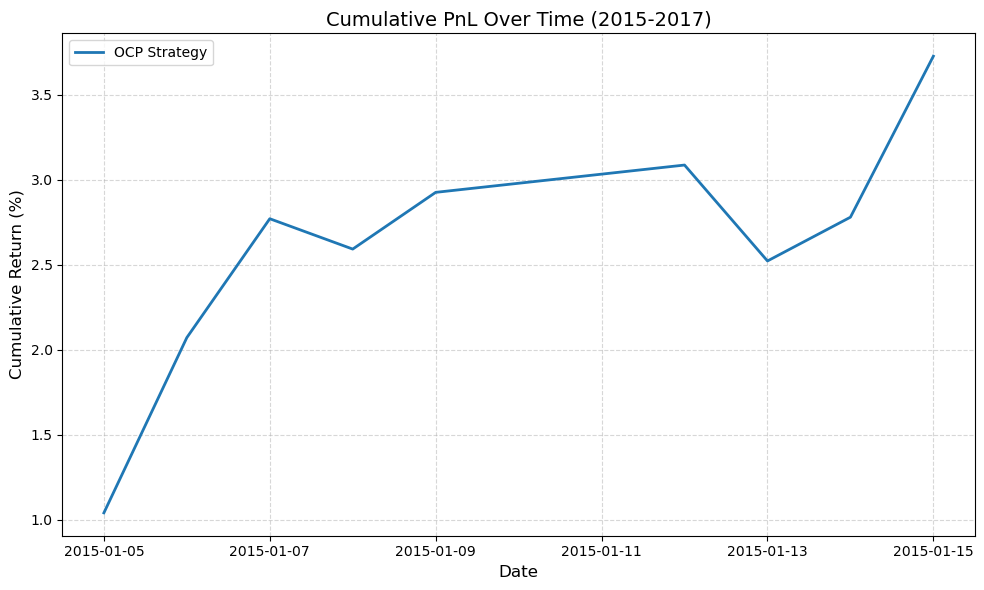

Saved: data/results_plots/cumulative_returns.png


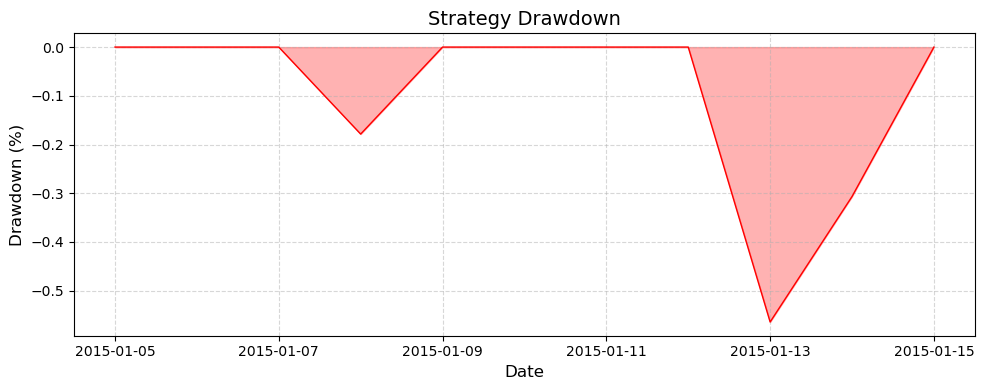

Saved: data/results_plots/drawdown.png


In [13]:
show_final_strat_results(results)

Starting Sensitivity Analysis on 7 thresholds...
Testing r_bps = 4 ...
Testing r_bps = 6 ...
Testing r_bps = 8 ...
Testing r_bps = 10 ...
Testing r_bps = 12 ...
Testing r_bps = 15 ...
Testing r_bps = 20 ...


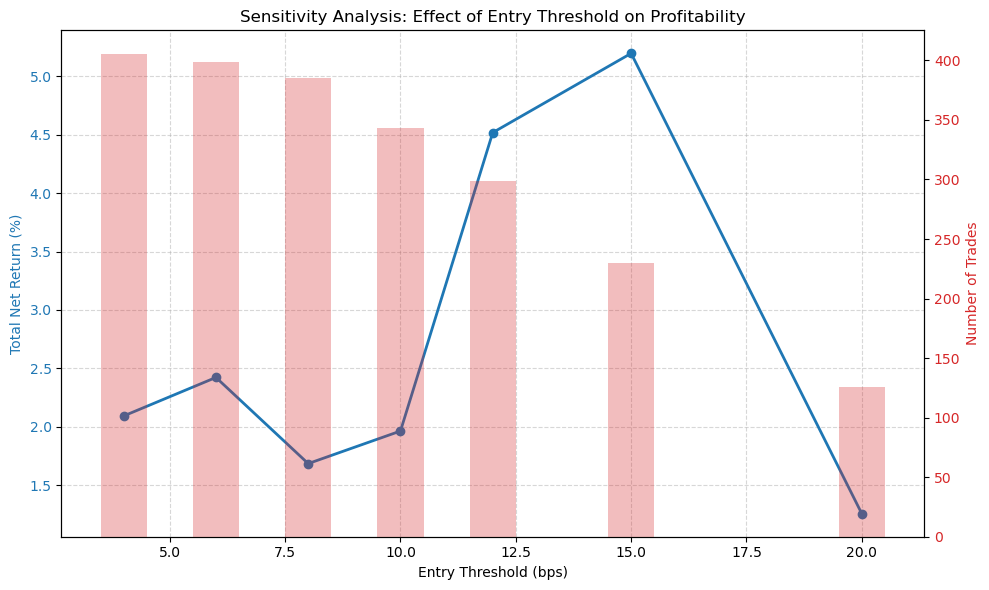

Sensitivity plot saved to: data/results_plots/sensitivity_analysis.png


In [14]:
show_sensitivity_analysis(PAIRS_PATH)